In [2]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d
from scipy.stats import entropy
from scipy.fft import fft
from scipy.signal import find_peaks
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_class_weight

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [3]:
train_df = pd.read_csv("data/exoTrain.csv")
test_df = pd.read_csv("data/exoTest.csv")

In [4]:
train_df.head()
train_df.shape
test_df.shape

(570, 3198)

In [5]:
train_df.isnull().sum().sum()

0

In [6]:
train_df["LABEL"].value_counts()

LABEL
1    5050
2      37
Name: count, dtype: int64

In [7]:
planet = (train_df["LABEL"]==2).sum()
nonplanet = (train_df["LABEL"]==1).sum()

print("Planets :",planet)
print("Non Planets :",nonplanet)

Planets : 37
Non Planets : 5050


In [8]:
train_df["LABEL"] = train_df["LABEL"].replace({1:0, 2:1})
test_df["LABEL"] = test_df["LABEL"].replace({1:0, 2:1})

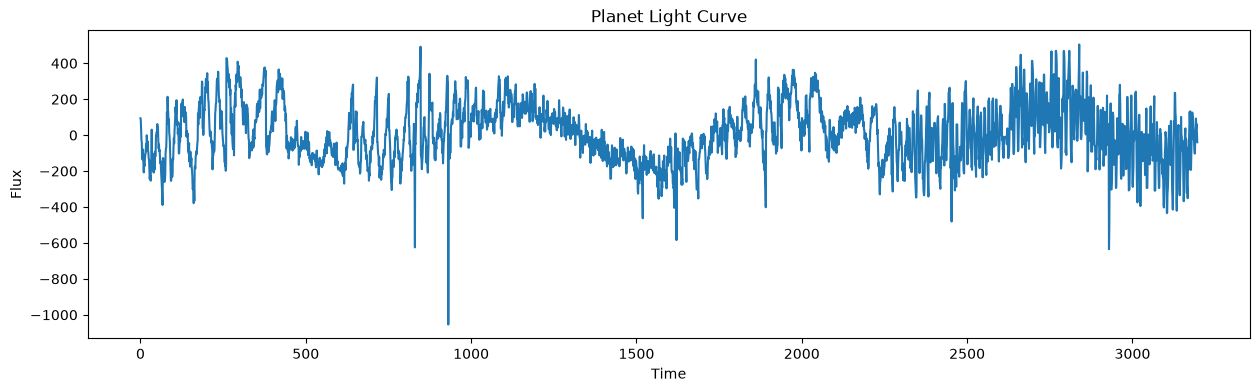

In [9]:
planet = train_df[train_df["LABEL"]==1].iloc[0]
flux = planet.iloc[1:].values
time = np.arange(len(flux))

plt.figure(figsize=(15,4))
plt.plot(time,flux)
plt.title("Planet Light Curve")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.show()

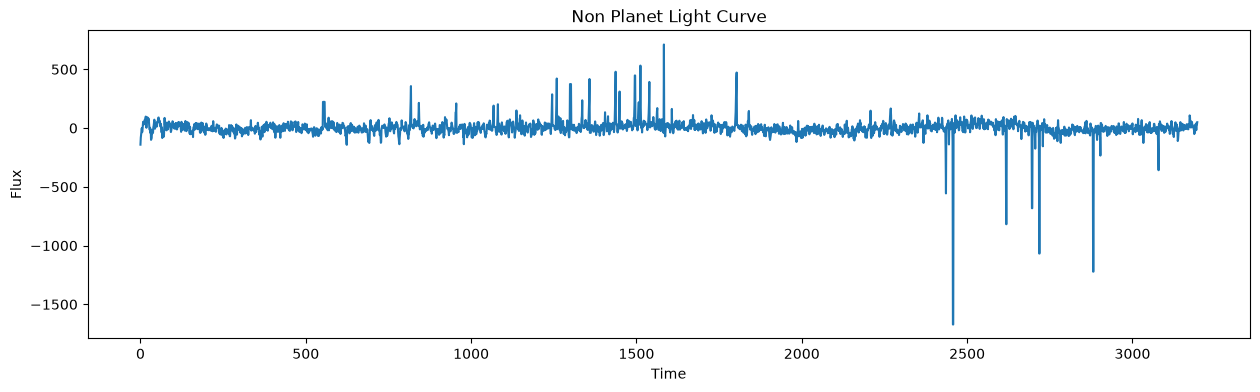

In [10]:
nonplanet = train_df[train_df["LABEL"]==0].iloc[0]
flux = nonplanet.iloc[1:].values
time = np.arange(len(flux))

plt.figure(figsize=(15,4))
plt.plot(time,flux)
plt.title("Non Planet Light Curve")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.show()

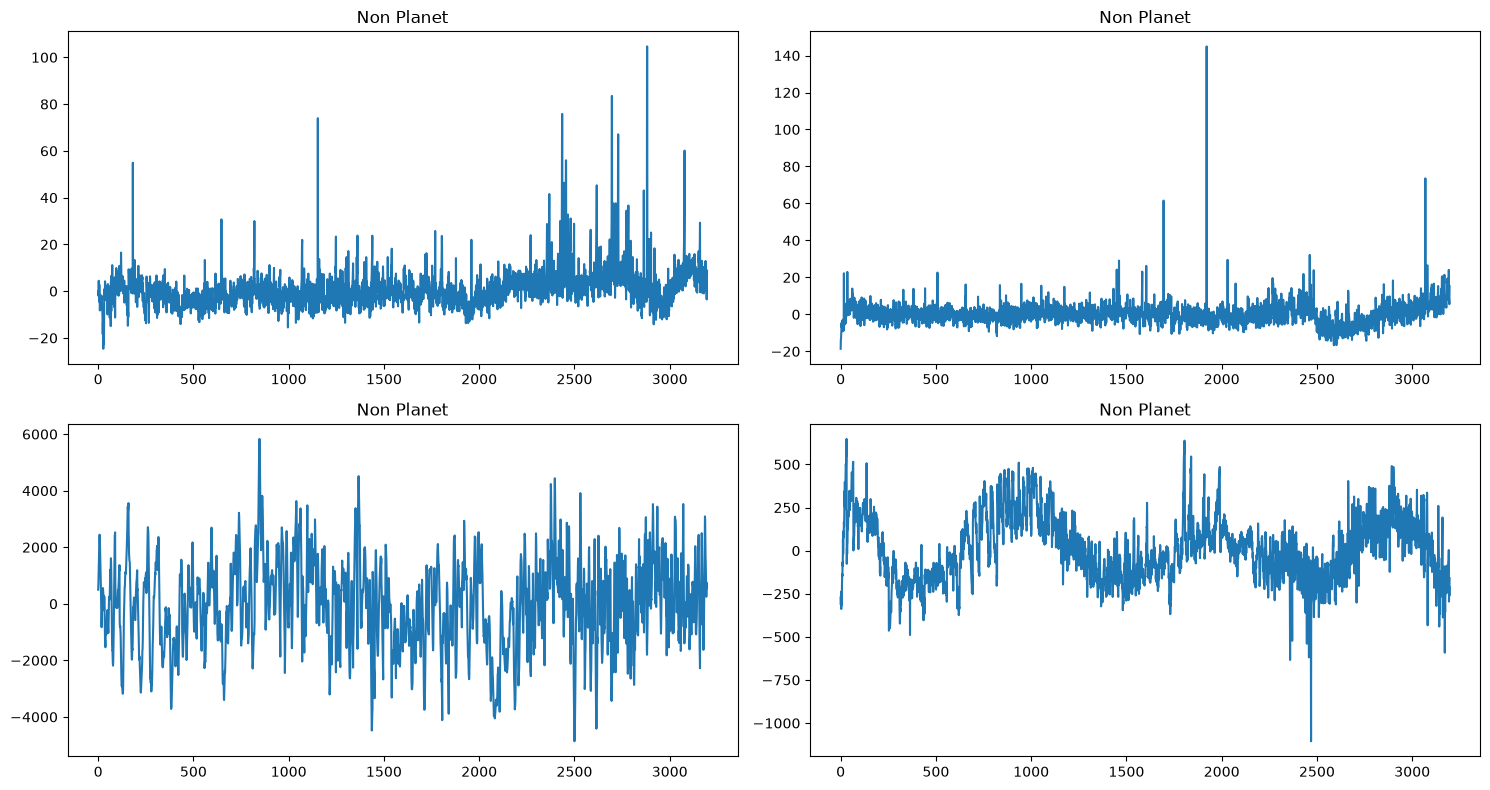

In [11]:
fig,axes = plt.subplots(2,2,figsize=(15,8))

samples=train_df.sample(4)

for ax,(_,row) in zip(axes.flatten(),samples.iterrows()):
    flux=row.iloc[1:].values
    time=np.arange(len(flux))
    ax.plot(time,flux)

    ax.set_title("Planet" if row["LABEL"]==1 else "Non Planet")

plt.tight_layout()
plt.show()

# Preprocessing

In [12]:
def moving_average(flux,window=25):
    return uniform_filter1d(flux,size=window)

In [13]:
def normalize(flux):
    flux = np.array(flux)
    
    return (flux-np.mean(flux))/np.std(flux)

In [14]:
def preprocess(flux):
    flux = moving_average(flux)
    flux = normalize(flux)

    return flux

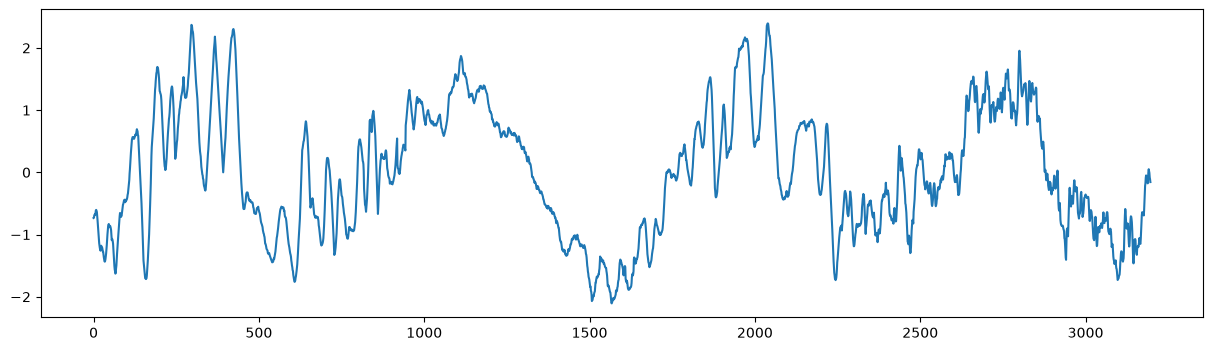

In [15]:
flux = train_df.iloc[0,1:].values
processed = preprocess(flux)

plt.figure(figsize=(15,4))
plt.plot(processed)
plt.show()

# Dip Detection

In [16]:
def detect_dips(flux):
    peaks,_=find_peaks(-flux,prominence=1)

    return peaks

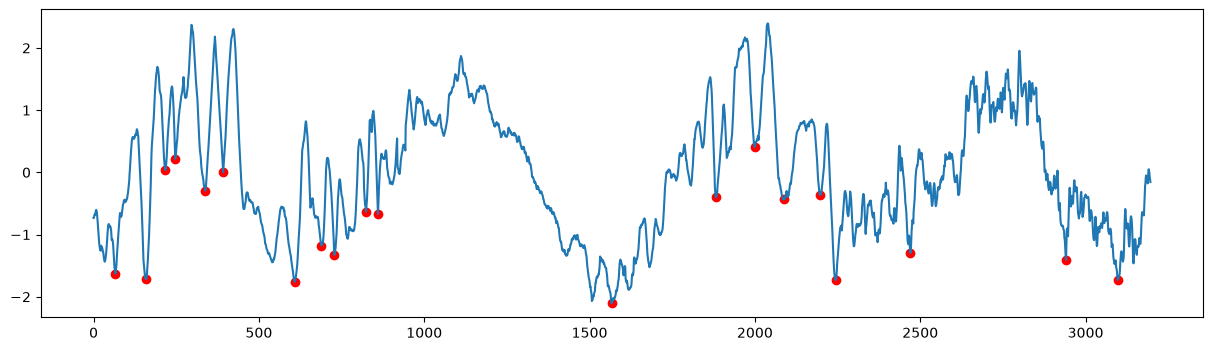

In [17]:
flux=preprocess(train_df.iloc[0,1:].values)
dips=detect_dips(flux)

plt.figure(figsize=(15,4))
plt.plot(flux)
plt.scatter(dips, flux[dips], color="red")
plt.show()

In [18]:
flux=train_df.iloc[0,1:].values

print("Mean :",np.mean(flux))
print("Median :",np.median(flux))
print("Std :",np.std(flux))
print("Min :",np.min(flux))
print("Max :",np.max(flux))

Mean : 9.953856740694402
Median : -0.01
Std : 160.7033479717893
Min : -1053.97
Max : 504.46


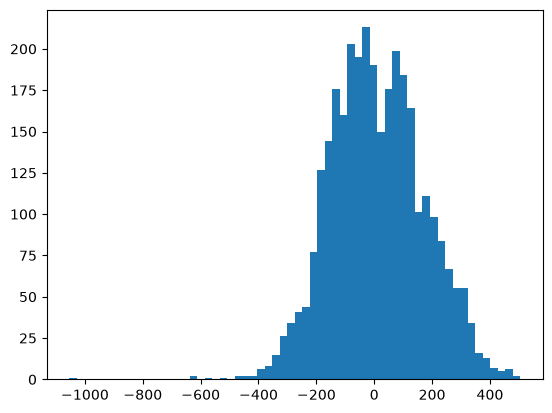

In [19]:
plt.hist(flux,bins=60)
plt.show()

# Feature Engineering

In [20]:
def statistical_features(flux):
    features = {}

    features["mean"] = np.mean(flux)
    features["median"] = np.median(flux)
    features["std"] = np.std(flux)
    features["variance"] = np.var(flux)
    features["minimum"] = np.min(flux)
    features["maximum"] = np.max(flux)
    features["range"] = np.ptp(flux)
    features["rms"] = np.sqrt(np.mean(flux**2))
    features["mad"] = np.mean(np.abs(flux - np.mean(flux)))
    features["iqr"] = np.percentile(flux,75) - np.percentile(flux,25)
    features["skewness"] = skew(flux)
    features["kurtosis"] = kurtosis(flux)

    return features

In [21]:
def signal_features(flux):
    features = {}
    diff = np.diff(flux)

    features["signal_energy"] = np.sum(flux**2)
    features["mean_absolute"] = np.mean(np.abs(flux))
    features["mean_abs_diff"] = np.mean(np.abs(diff))
    features["noise_level"] = np.std(diff)
    features["max_slope"] = np.max(np.abs(diff))
    features["peak_to_peak"] = np.ptp(flux)

    return features

In [22]:
flux = train_df.iloc[0,1:].values.astype(float)
stats = statistical_features(flux)

stats

{'mean': 9.953856740694402,
 'median': -0.01,
 'std': 160.7033479717893,
 'variance': 25825.566049342,
 'minimum': -1053.97,
 'maximum': 504.46,
 'range': 1558.43,
 'rms': 161.01132045094306,
 'mad': 129.76898916905697,
 'iqr': 222.08,
 'skewness': 0.004391943624776552,
 'kurtosis': 0.40833845547245984}

In [23]:
def dip_features(flux):
    features = {}

    threshold = np.mean(flux) - 2.5*np.std(flux)
    dips = flux[flux < threshold]
    features["num_dips"] = len(dips)

    if len(dips) > 0:
        features["deepest_dip"] = np.min(dips)
        features["average_dip"] = np.mean(dips)
        features["dip_std"] = np.std(dips)
        features["dip_density"] = len(dips)/len(flux)

    else:
        features["deepest_dip"] = 0
        features["average_dip"] = 0
        features["dip_std"] = 0
        features["dip_density"] = 0

    return features

In [24]:
def frequency_features(flux):
    features = {}

    fft_values = np.abs(fft(flux))
    fft_values = fft_values[:len(fft_values)//2]

    features["fft_energy"] = np.sum(fft_values**2)
    dominant = np.argmax(fft_values[1:]) + 1

    features["dominant_frequency"] = dominant
    prob = fft_values / np.sum(fft_values)
    
    features["spectral_entropy"] = entropy(prob)

    return features

In [25]:
def correlation_features(flux):
    features = {}

    features["lag1_autocorrelation"] = np.corrcoef(flux[:-1], flux[1:])[0,1]
    features["lag5_autocorrelation"] = np.corrcoef(flux[:-5], flux[5:])[0,1]

    zero_crossings = np.where(np.diff(np.sign(flux)))[0]
    features["zero_crossings"] = len(zero_crossings)

    return features

In [26]:
def shape_features(flux):
    features = {}

    features["positive_ratio"] = np.mean(flux > 0)
    features["negative_ratio"] = np.mean(flux < 0)
    peak = np.max(np.abs(flux))
    rms = np.sqrt(np.mean(flux**2))
    mean_abs = np.mean(np.abs(flux))
    features["crest_factor"] = peak/rms
    features["impulse_factor"] = peak/mean_abs

    return features

In [27]:
from scipy.signal import find_peaks, peak_widths, peak_prominences

In [28]:
def peak_features(flux):
    features = {
        "num_peaks": 0,
        "avg_peak_prominence": 0,
        "max_peak_prominence": 0,
        "avg_peak_width": 0,
        "peak_spacing": 0
    }

    inverted_flux = -flux
    peaks, _ = find_peaks(inverted_flux, prominence=np.std(flux))

    if len(peaks) == 0:
        return features

    prominences = peak_prominences(inverted_flux, peaks)[0]
    widths = peak_widths(inverted_flux, peaks, rel_height=0.5)[0]

    features["num_peaks"] = len(peaks)
    features["avg_peak_prominence"] = np.mean(prominences)
    features["max_peak_prominence"] = np.max(prominences)
    features["avg_peak_width"] = np.mean(widths)

    if len(peaks) > 1:
        features["peak_spacing"] = np.mean(np.diff(peaks))

    return features

In [29]:
def variability_features(flux):
    features = {}
    window = 25
    rolling_std = []
    rolling_mean = []

    for i in range(len(flux)-window):
        segment = flux[i:i+window]
        rolling_std.append(np.std(segment))
        rolling_mean.append(np.mean(segment))

    rolling_std = np.array(rolling_std)
    rolling_mean = np.array(rolling_mean)

    features["rolling_std_mean"] = np.mean(rolling_std)
    features["rolling_std_max"] = np.max(rolling_std)
    features["rolling_std_std"] = np.std(rolling_std)
    features["rolling_mean_std"] = np.std(rolling_mean)

    return features

In [30]:
def distribution_features(flux):
    features = {}

    p10 = np.percentile(flux,10)
    p25 = np.percentile(flux,25)
    p75 = np.percentile(flux,75)
    p90 = np.percentile(flux,90)

    features["percentile_ratio"] = abs(p90)/(abs(p10)+1e-8)
    features["flux_cv"] = np.std(flux)/(abs(np.mean(flux))+1e-8)
    features["outlier_fraction"] = np.mean(np.abs(flux-np.mean(flux)) > 3*np.std(flux))
    features["quartile_dispersion"] = ((p75-p25)/(p75+p25+1e-8))

    return features

In [31]:
def transit_morphology_features(flux):
    features = {}
    threshold = np.mean(flux) - 2.5*np.std(flux)
    dip_indices = np.where(flux < threshold)[0]

    if len(dip_indices) == 0:
        features["max_transit_duration"] = 0
        features["avg_transit_duration"] = 0
        features["num_transits"] = 0
        features["symmetry_score"] = 0
        features["avg_ingress_egress_ratio"] = 0

        return features

    groups = np.split(dip_indices, np.where(np.diff(dip_indices) != 1)[0] + 1)

    durations = []
    symmetry = []
    slope_ratio = []

    for group in groups:
        start = group[0]
        end = group[-1]

        durations.append(end - start + 1)
        center = (start + end)//2

        left = flux[start:center+1]
        right = flux[center:end+1]

        if len(left) > 1 and len(right) > 1:
            left_slope = np.mean(np.abs(np.diff(left)))
            right_slope = np.mean(np.abs(np.diff(right)))

            slope_ratio.append(min(left_slope, right_slope) / (max(left_slope, right_slope)+1e-8))

            left_depth = np.mean(left)
            right_depth = np.mean(right)

            symmetry.append(1 - abs(left_depth-right_depth)/ (abs(left_depth)+abs(right_depth)+1e-8))

    features["max_transit_duration"] = np.max(durations)
    features["avg_transit_duration"] = np.mean(durations)
    features["num_transits"] = len(groups)

    if len(symmetry):
        features["symmetry_score"] = np.mean(symmetry)
    else:
        features["symmetry_score"] = 0

    if len(slope_ratio):
        features["avg_ingress_egress_ratio"] = np.mean(slope_ratio)
    else:
        features["avg_ingress_egress_ratio"] = 0

    return features

In [32]:
def extract_features(flux):
    features = {}

    features.update(statistical_features(flux))
    features.update(signal_features(flux))
    features.update(dip_features(flux))
    features.update(frequency_features(flux))
    features.update(correlation_features(flux))
    features.update(shape_features(flux))
    features.update(peak_features(flux))
    features.update(variability_features(flux))
    features.update(distribution_features(flux))
    features.update(transit_morphology_features(flux))

    return features

In [33]:
features = extract_features(flux)

print(f"Total Features : {len(features)}\n")

for key, value in features.items():
    print(f"{key:35s} : {value}")

Total Features : 51

mean                                : 9.953856740694402
median                              : -0.01
std                                 : 160.7033479717893
variance                            : 25825.566049342
minimum                             : -1053.97
maximum                             : 504.46
range                               : 1558.43
rms                                 : 161.01132045094306
mad                                 : 129.76898916905697
iqr                                 : 222.08
skewness                            : 0.004391943624776552
kurtosis                            : 0.40833845547245984
signal_energy                       : 82881091.0668
mean_absolute                       : 129.5780043791054
mean_abs_diff                       : 56.49388923654569
noise_level                         : 88.68425901945179
max_slope                           : 1346.92
peak_to_peak                        : 1558.43
num_dips                            : 15
de

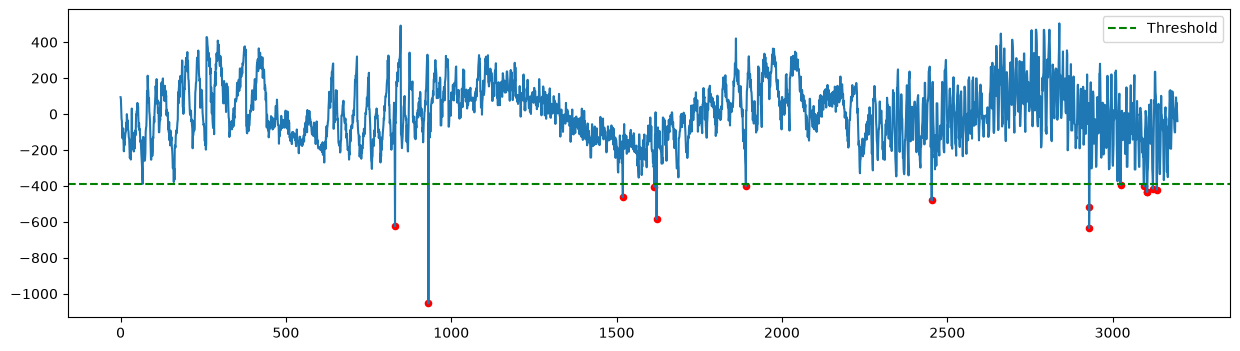

In [34]:
threshold = np.mean(flux) - 2.5 * np.std(flux)
dip_indices = np.where(flux<threshold)[0]

plt.figure(figsize=(15,4))
plt.plot(flux)
plt.scatter(dip_indices, flux[dip_indices], color="red", s=20)
plt.axhline(threshold, color="green", linestyle="--", label="Threshold")
plt.legend()
plt.show()

# Creating Feature Dataset

In [35]:
from tqdm import tqdm

In [36]:
def create_feature_dataset(df):
    feature_rows = []
    labels = []
    flux_columns = df.columns[1:]

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting Features"):
        flux = row[flux_columns].values.astype(float)
        feature_dict = extract_features(flux)

        for key, value in feature_dict.items():
            if np.isnan(value) or np.isinf(value):
                feature_dict[key] = 0

        feature_rows.append(feature_dict)
        labels.append(row["LABEL"])

    feature_df = pd.DataFrame(feature_rows)
    feature_df["LABEL"] = labels

    expected_features = 51

    if len(feature_dict) != expected_features:
        raise ValueError(
            f"Expected {expected_features} features, got {len(feature_dict)}"
        )

    return feature_df

In [37]:
train_features = create_feature_dataset(train_df)

train_features.head()

Extracting Features: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5087/5087 [08:29<00:00,  9.99it/s]


,mean,median,std,variance,minimum,maximum,range,rms,mad,iqr,...,percentile_ratio,flux_cv,outlier_fraction,quartile_dispersion,max_transit_duration,avg_transit_duration,num_transits,symmetry_score,avg_ingress_egress_ratio,LABEL
0,9.953857,-0.01,160.703348,25825.566049,-1053.97,504.46,1558.43,161.011320,129.768989,222.08,...,1.215274,16.144832,0.002502,14.534031,2,1.153846,13,0.000000,0.000000,1.0
1,-7.427932,0.01,60.001638,3600.196539,-371.27,252.64,623.91,60.459662,36.276969,46.61,...,0.823071,8.077838,0.032843,-12.429333,8,3.354839,31,0.952663,0.497345,1.0
2,8.189087,-0.08,281.832397,79429.499717,-874.95,1274.59,2149.54,281.951345,202.966629,287.98,...,0.944873,34.415608,0.013450,10.055168,6,3.090909,11,0.983463,0.280818,1.0
3,-4.646587,-0.01,103.222575,10654.900069,-268.41,370.29,638.70,103.327106,83.730053,147.71,...,0.816007,22.214706,0.007194,-17.036909,2,2.000000,2,0.000000,0.000000,1.0
4,-14.240660,0.02,407.057614,165695.901414,-1808.76,924.32,2733.08,407.306639,324.827361,583.49,...,0.768911,28.584182,0.002502,12.333333,6,3.111111,9,0.958178,0.397942,1.0


In [38]:
test_features = create_feature_dataset(test_df)

test_features.head()

Extracting Features: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 570/570 [00:51<00:00, 11.16it/s]


,mean,median,std,variance,minimum,maximum,range,rms,mad,iqr,...,percentile_ratio,flux_cv,outlier_fraction,quartile_dispersion,max_transit_duration,avg_transit_duration,num_transits,symmetry_score,avg_ingress_egress_ratio,LABEL
0,0.730823,0.00,29.811801,8.887435e+02,-166.46,269.43,435.89,29.820758,20.899226,32.43,...,0.945297,40.792115,0.016578,-61.188680,4,1.888889,9,0.852851,0.484698,1.0
1,95.413363,-0.67,1644.761812,2.705241e+06,-6105.72,8210.62,14316.34,1647.526973,1239.157789,1856.09,...,1.200290,17.238275,0.009384,11.614355,4,2.777778,9,0.974703,0.308812,1.0
2,-6.035136,-0.05,117.058557,1.370271e+04,-467.74,844.48,1312.22,117.214029,87.612976,139.25,...,0.816292,19.396175,0.011886,-14.311408,7,2.235294,17,0.955167,0.517641,1.0
3,-62.032740,0.00,394.445070,1.555869e+05,-2780.75,500.72,3281.47,399.293093,176.355508,155.10,...,0.943821,6.358659,0.027213,8.285256,9,4.500000,20,0.930964,0.340818,1.0
4,-23.669312,0.01,177.015316,3.133442e+04,-1956.93,316.45,2273.38,178.590757,81.323049,81.97,...,0.748170,7.478685,0.016578,-103.759495,9,3.055556,18,0.927319,0.301573,1.0


In [39]:
print("Train Shape :", train_features.shape)
print("Test Shape  :", test_features.shape)

print("\nMissing Values")
print(train_features.isnull().sum().sum())
print(test_features.isnull().sum().sum())

Train Shape : (5087, 52)
Test Shape  : (570, 52)

Missing Values
0
0


# Feature Analysis & Selection

In [40]:
X_train = train_features.drop(columns=["LABEL"])
y_train = train_features["LABEL"]

X_test = test_features.drop(columns=["LABEL"])
y_test = test_features["LABEL"]

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

Training Features: (5087, 51)
Testing Features : (570, 51)


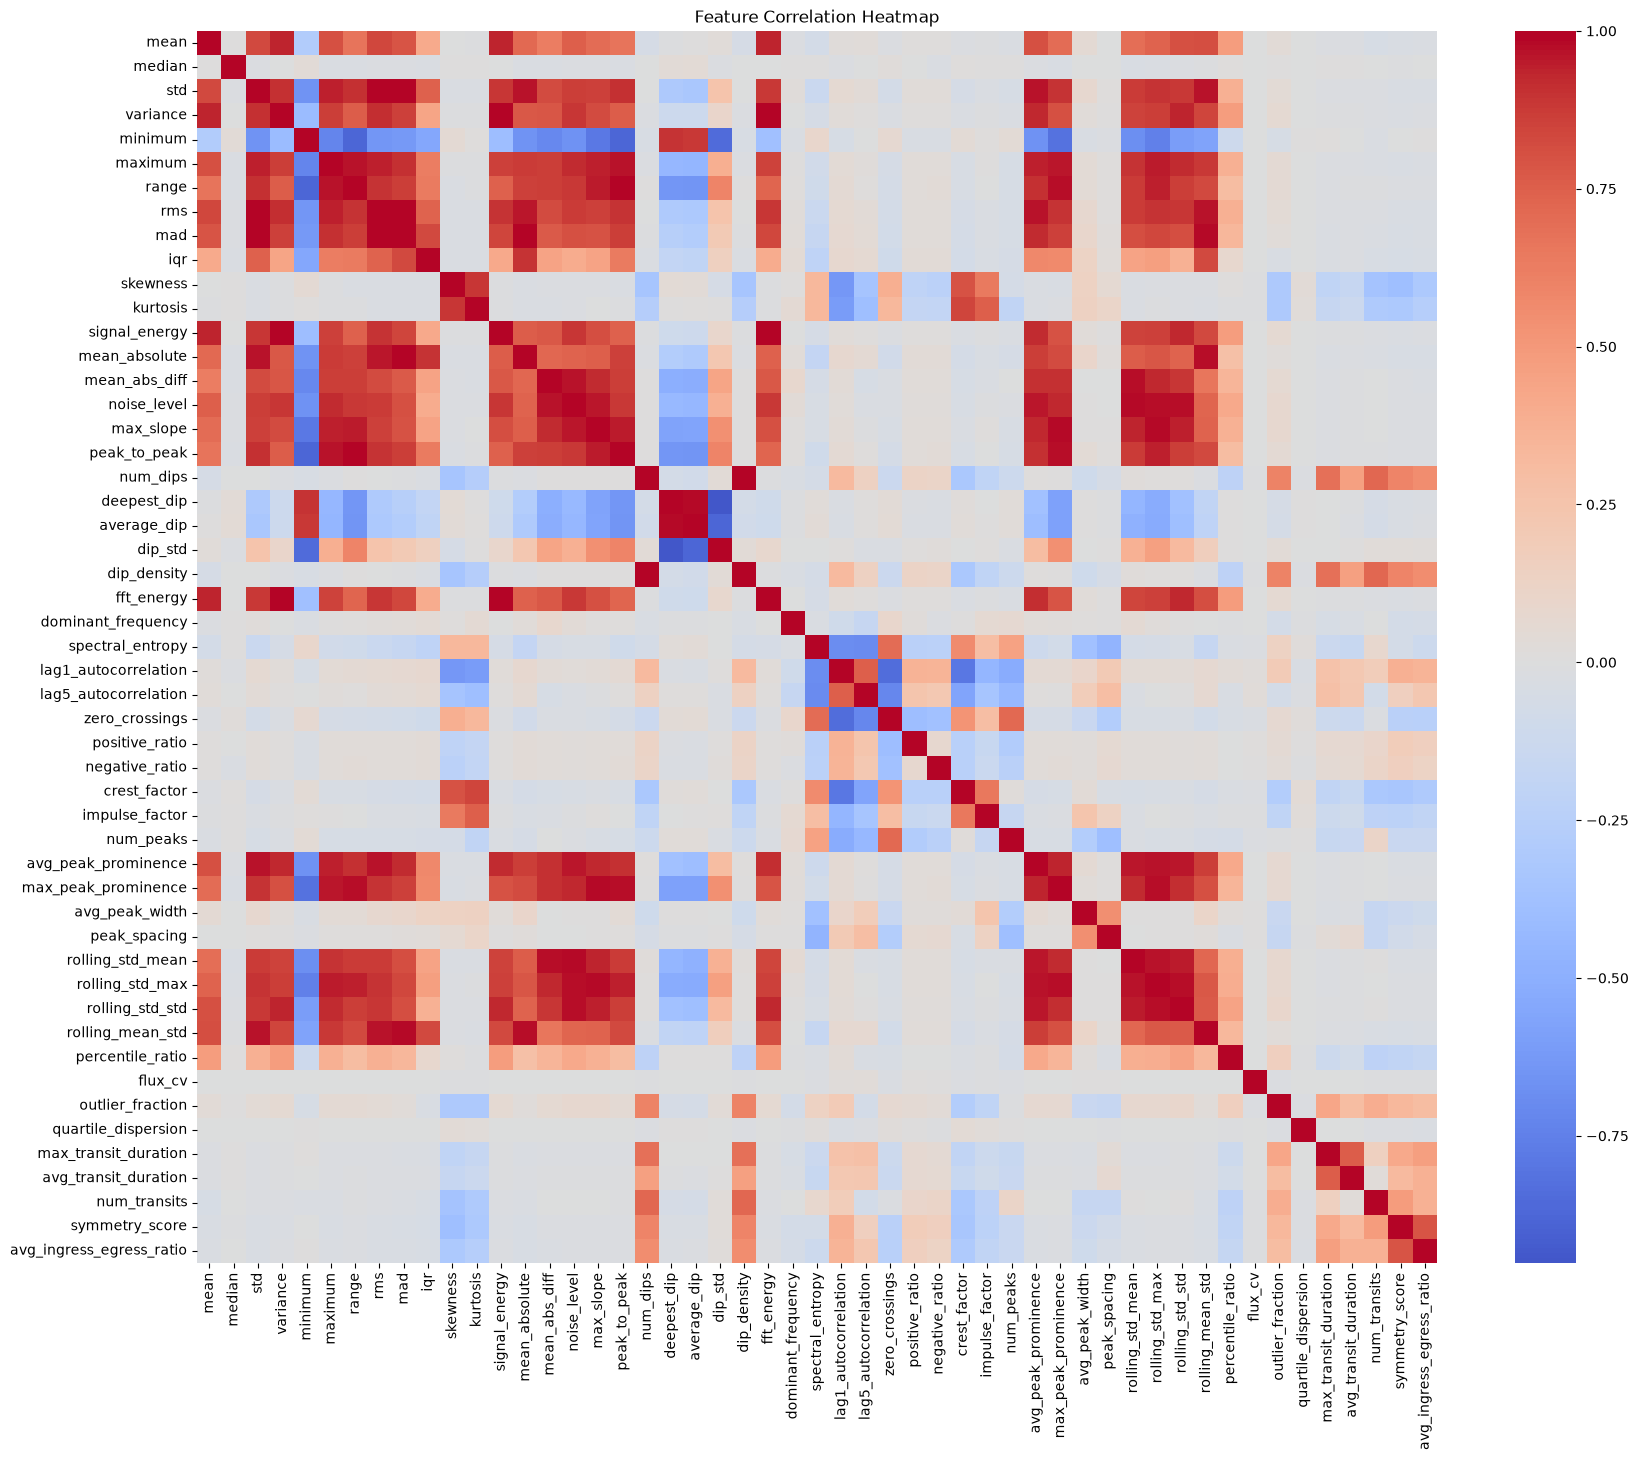

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,16))
sns.heatmap(X_train.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [42]:
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = []

for column in upper.columns:
    for row in upper.index:
        if upper.loc[row, column] > 0.90:
            high_corr.append((row, column, upper.loc[row, column]))

high_corr = sorted(high_corr, key=lambda x: x[2], reverse=True)

print("Highly Correlated Features (>0.90)\n")

for feature1, feature2, corr in high_corr:
    print(f"{feature1:30s} {feature2:30s} {corr:.3f}")

Highly Correlated Features (>0.90)

range                          peak_to_peak                   1.000
num_dips                       dip_density                    1.000
signal_energy                  fft_energy                     1.000
std                            rms                            1.000
variance                       signal_energy                  1.000
variance                       fft_energy                     0.998
std                            mad                            0.990
mad                            mean_absolute                  0.989
rms                            mad                            0.988
max_slope                      rolling_std_max                0.985
noise_level                    rolling_std_mean               0.983
deepest_dip                    average_dip                    0.982
mad                            rolling_mean_std               0.982
max_slope                      max_peak_prominence            0.979
noise_level 

In [43]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_scores = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

print(mi_scores)

median                      0.034306
negative_ratio              0.020028
positive_ratio              0.011829
spectral_entropy            0.004247
skewness                    0.003634
peak_spacing                0.003593
mean_abs_diff               0.003578
lag1_autocorrelation        0.003206
mad                         0.003008
avg_peak_prominence         0.002978
signal_energy               0.002971
std                         0.002921
variance                    0.002834
iqr                         0.002752
rolling_std_mean            0.002712
rolling_mean_std            0.002710
mean_absolute               0.002504
fft_energy                  0.002403
max_transit_duration        0.002346
kurtosis                    0.002176
crest_factor                0.002131
num_peaks                   0.002008
rolling_std_std             0.001991
rms                         0.001968
dominant_frequency          0.001924
num_dips                    0.001836
mean                        0.001794
z

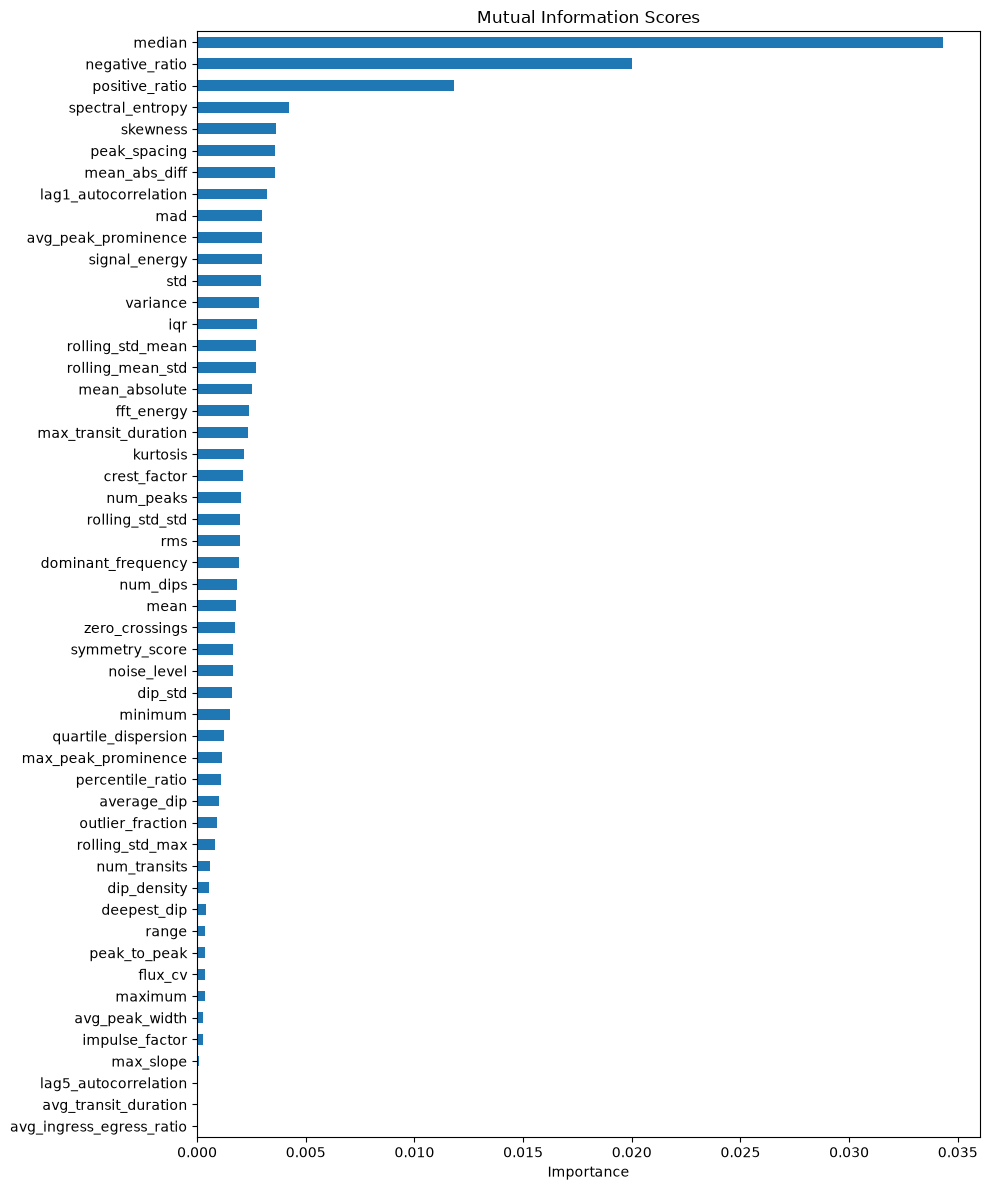

In [44]:
plt.figure(figsize=(10,12))

mi_scores.sort_values().plot(kind="barh")

plt.title("Mutual Information Scores")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [45]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

print(importance)

median                      0.293824
negative_ratio              0.213603
positive_ratio              0.146971
mean                        0.010500
percentile_ratio            0.010224
lag5_autocorrelation        0.009922
symmetry_score              0.008975
quartile_dispersion         0.008965
fft_energy                  0.008742
range                       0.008709
crest_factor                0.008656
skewness                    0.008605
kurtosis                    0.008450
peak_spacing                0.008355
flux_cv                     0.008234
num_transits                0.008182
dip_density                 0.008137
avg_ingress_egress_ratio    0.008123
rolling_std_std             0.007862
num_peaks                   0.007747
deepest_dip                 0.007626
rolling_std_mean            0.007616
num_dips                    0.007569
avg_transit_duration        0.007261
lag1_autocorrelation        0.007205
avg_peak_prominence         0.007169
impulse_factor              0.007127
s

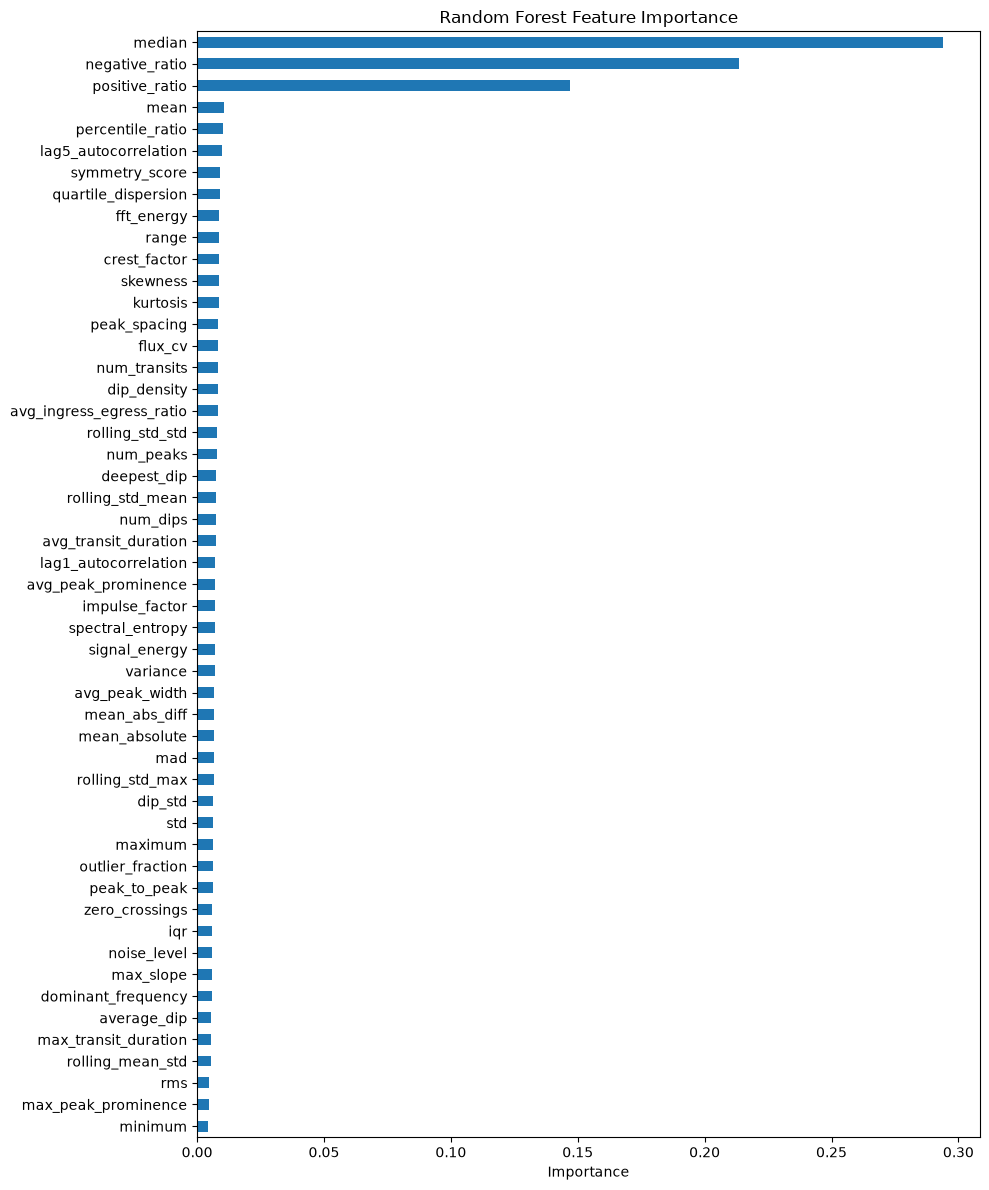

In [46]:
plt.figure(figsize=(10,12))
importance.sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Remove Redundant Features

In [47]:
features_to_drop = [
    "variance",          
    "peak_to_peak",       
    "dip_density",       
    "fft_energy",        
]

X_train_reduced = X_train.drop(columns=features_to_drop)
X_test_reduced = X_test.drop(columns=features_to_drop)

print("Original Features :", X_train.shape[1])
print("Reduced Features  :", X_train_reduced.shape[1])

Original Features : 51
Reduced Features  : 47


# Correlation-Based Feature Removal

In [48]:
corr_matrix = X_train_reduced.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_corr = [column for column in upper.columns if any(upper[column] > 0.95)]

print("Features to remove due to high correlation:\n")
print(drop_corr)

print("\nNumber of features removed:", len(drop_corr))

Features to remove due to high correlation:

['range', 'rms', 'mad', 'mean_absolute', 'noise_level', 'max_slope', 'average_dip', 'dip_std', 'avg_peak_prominence', 'max_peak_prominence', 'rolling_std_mean', 'rolling_std_max', 'rolling_std_std', 'rolling_mean_std']

Number of features removed: 14


In [49]:
X_train_final = X_train_reduced.drop(columns=drop_corr)
X_test_final = X_test_reduced.drop(columns=drop_corr)

print("Final Feature Count:", X_train_final.shape[1])

Final Feature Count: 33


In [50]:
k_values = [10, 15, 20, 25, 30, 33]
results = []

for k in k_values:
    selector = SelectKBest(mutual_info_classif, k=k)

    X_train_selected = selector.fit_transform(X_train_final, y_train)
    X_test_selected = selector.transform(X_test_final)

    model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(X_train_selected, y_train)

    prediction = model.predict(X_test_selected)
    score = f1_score(y_test, prediction)

    results.append((k, score))

results = pd.DataFrame(results, columns=["Features", "F1 Score"])

results

,Features,F1 Score
0,10,0.75
1,15,0.75
2,20,0.75
3,25,0.75
4,30,0.75
5,33,0.75


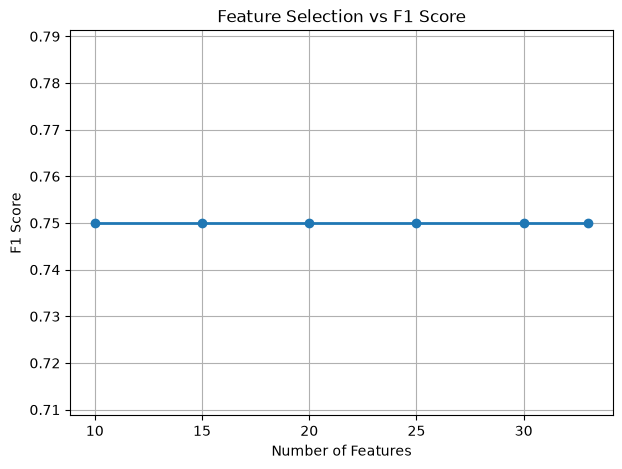

In [51]:
plt.figure(figsize=(7,5))

plt.plot(
    results["Features"],
    results["F1 Score"],
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Features")
plt.ylabel("F1 Score")

plt.title("Feature Selection vs F1 Score")
plt.grid(True)
plt.show()

### Observation

Different values of k (10–33) produced the same F1-score of 0.75 on the test set.
This indicates that additional feature reduction using Mutual Information did not
improve Random Forest performance.

Therefore, the final model uses the 33 features obtained after correlation-based
feature elimination (|r| > 0.95).

In [52]:
X_train_tree = X_train_final.copy()
X_test_tree = X_test_final.copy()

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

print("Scaled dataset ready!")

Scaled dataset ready!


In [54]:
print("Training Set")
print(y_train.value_counts())

print("\nTesting Set")
print(y_test.value_counts())

Training Set
LABEL
0.0    5050
1.0      37
Name: count, dtype: int64

Testing Set
LABEL
0.0    565
1.0      5
Name: count, dtype: int64


# Model Training and Evaluation

In [55]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("=" * 60)
    print(f"{model_name}")
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    if y_prob is not None:
        auc = roc_auc_score(y_test, y_prob)
        print(f"ROC-AUC  : {auc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot(cmap="Blues")

    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    return {
    "Model": model_name,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else None,
    "Predictions": y_pred
    }

Logistic Regression
Accuracy : 0.8596
Precision: 0.0370
Recall   : 0.6000
F1 Score : 0.0698
ROC-AUC  : 0.6973

Classification Report

              precision    recall  f1-score   support

         0.0       1.00      0.86      0.92       565
         1.0       0.04      0.60      0.07         5

    accuracy                           0.86       570
   macro avg       0.52      0.73      0.50       570
weighted avg       0.99      0.86      0.92       570



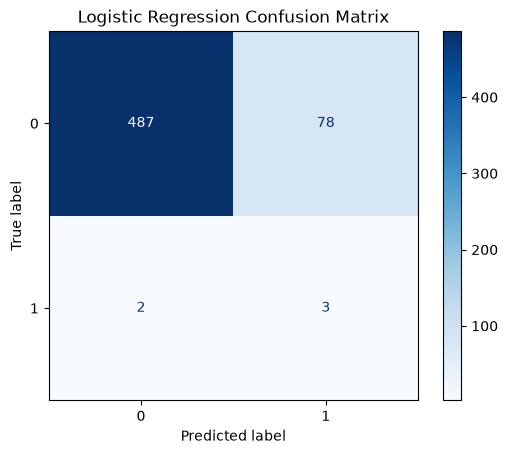

In [56]:
log_reg = LogisticRegression(class_weight="balanced", random_state=42, max_iter=5000)
log_results = evaluate_model(log_reg, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression")

Random Forest
Accuracy : 0.9965
Precision: 1.0000
Recall   : 0.6000
F1 Score : 0.7500
ROC-AUC  : 0.9350

Classification Report

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       565
         1.0       1.00      0.60      0.75         5

    accuracy                           1.00       570
   macro avg       1.00      0.80      0.87       570
weighted avg       1.00      1.00      1.00       570



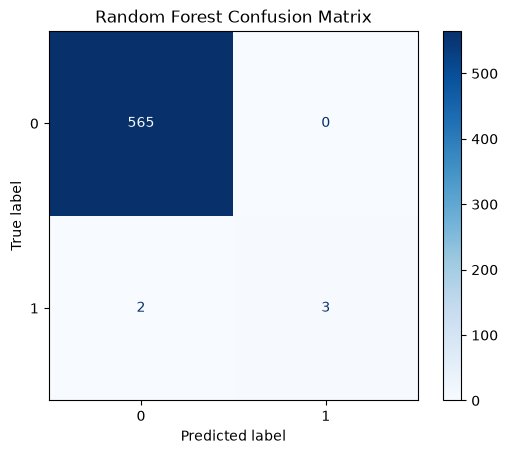

In [57]:
rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced", n_jobs=-1)
rf_results = evaluate_model(rf, X_train_tree, X_test_tree, y_train, y_test, "Random Forest")

# Threshold Analysis

In [58]:
y_prob = rf.predict_proba(X_test_tree)[:, 1]
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append([t, precision, recall, f1])

threshold_results = pd.DataFrame(results, columns = ["Threshold", "Precision", "Recall", "F1"])

threshold_results

,Threshold,Precision,Recall,F1
0,0.2,1.0,0.6,0.75
1,0.3,1.0,0.6,0.75
2,0.4,1.0,0.6,0.75
3,0.5,1.0,0.6,0.75
4,0.6,1.0,0.6,0.75
5,0.7,1.0,0.6,0.75


In [59]:
y_prob = rf.predict_proba(X_test_tree)[:, 1]

print("Minimum probability:", y_prob.min())
print("Maximum probability:", y_prob.max())

print("\nUnique probabilities:")
print(np.sort(y_prob)[-20:])

Minimum probability: 0.0
Maximum probability: 0.93

Unique probabilities:
[0.028 0.028 0.028 0.03  0.03  0.032 0.036 0.038 0.04  0.046 0.048 0.05
 0.054 0.056 0.06  0.084 0.176 0.74  0.926 0.93 ]


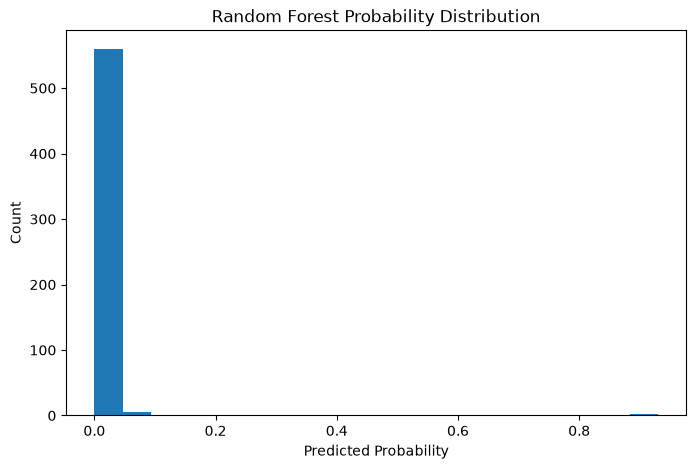

In [60]:
plt.figure(figsize=(8,5))

plt.hist(y_prob, bins=20)

plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Random Forest Probability Distribution")

plt.show()

In [61]:
param_grid = {
    "n_estimators" : [200,300,500,700],
    "max_depth" : [None,5,10,15,20,30],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,4],
    "max_features" : ["sqrt","log2"],
    "bootstrap" : [True,False]
}

In [62]:
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_distributions=param_grid, 
    n_iter=25, 
    scoring="f1",
    cv=5, 
    random_state=42, 
    n_jobs=-1, 
    verbose=2
    )
rf_search.fit(X_train_tree, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns th

In [63]:
print("Best Parameters\n")
print(rf_search.best_params_)

print("\nBest CV Score")
print(rf_search.best_score_)

Best Parameters

{'n_estimators': 700, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15, 'bootstrap': False}

Best CV Score
0.8387878787878789


Tuned Random Forest
Accuracy : 0.9965
Precision: 1.0000
Recall   : 0.6000
F1 Score : 0.7500
ROC-AUC  : 0.9228

Classification Report

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       565
         1.0       1.00      0.60      0.75         5

    accuracy                           1.00       570
   macro avg       1.00      0.80      0.87       570
weighted avg       1.00      1.00      1.00       570



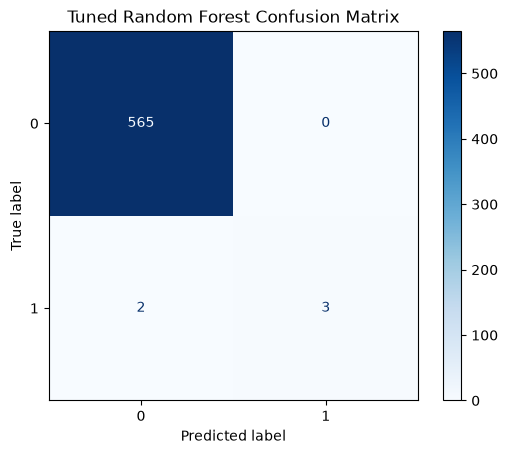

In [64]:
best_rf = rf_search.best_estimator_
best_rf_results = evaluate_model(best_rf, X_train_tree, X_test_tree, y_train, y_test, "Tuned Random Forest")

### Observation

Random Forest hyperparameter tuning was performed using RandomizedSearchCV with 5-fold cross-validation.

Although the tuned model achieved a cross-validation F1-score of 0.8388, its performance on the independent test set remained unchanged compared to the baseline model.

Therefore, the baseline Random Forest model was selected as the final Random Forest classifier because it achieved the same F1-score (0.75), the same recall (0.60), and a slightly higher ROC-AUC (0.935).

# XGBoost

In [65]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_weight = negative / positive

print(scale_weight)

136.48648648648648


XGBoost
Accuracy : 0.9965
Precision: 1.0000
Recall   : 0.6000
F1 Score : 0.7500
ROC-AUC  : 0.9058

Classification Report

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       565
         1.0       1.00      0.60      0.75         5

    accuracy                           1.00       570
   macro avg       1.00      0.80      0.87       570
weighted avg       1.00      1.00      1.00       570



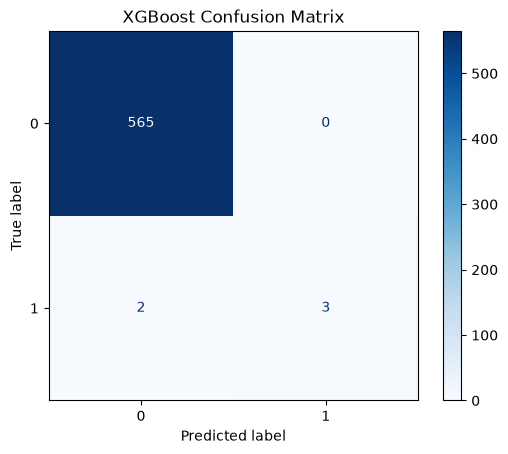

In [66]:
xgb = XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1)

xgb_results = evaluate_model(xgb, X_train_tree, X_test_tree, y_train, y_test, "XGBoost")

# SVM

Support Vector Machine
Accuracy : 0.9895
Precision: 0.4444
Recall   : 0.8000
F1 Score : 0.5714
ROC-AUC  : 0.8782

Classification Report

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       565
         1.0       0.44      0.80      0.57         5

    accuracy                           0.99       570
   macro avg       0.72      0.90      0.78       570
weighted avg       0.99      0.99      0.99       570



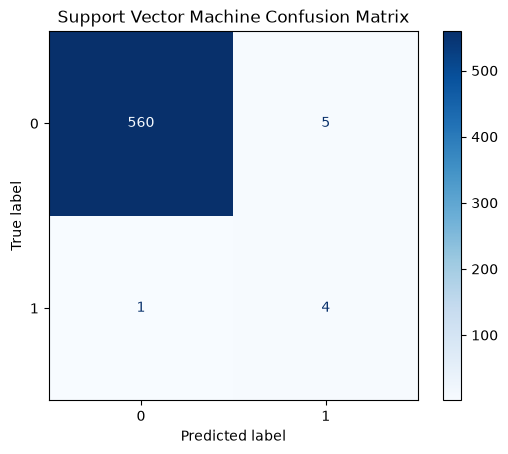

In [67]:
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm_results = evaluate_model(
    svm,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Support Vector Machine"
)

In [68]:
comparison = pd.DataFrame([
    log_results,
    rf_results,
    best_rf_results,
    xgb_results,
    svm_results
])

comparison = comparison.sort_values(
    by="F1 Score",
    ascending=False
)

comparison.reset_index(drop=True, inplace=True)
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Predictions
0,Random Forest,0.996491,1.000000,0.6,0.750000,0.935044,"[0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..."
1,Tuned Random Forest,0.996491,1.000000,0.6,0.750000,0.922832,"[0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..."
2,XGBoost,0.996491,1.000000,0.6,0.750000,0.905841,"[0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Support Vector Machine,0.989474,0.444444,0.8,0.571429,0.878230,"[0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..."
4,Logistic Regression,0.859649,0.037037,0.6,0.069767,0.697345,"[0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..."


In [69]:
comparison.to_csv(
    "data/model_comparison.csv",
    index=False
)

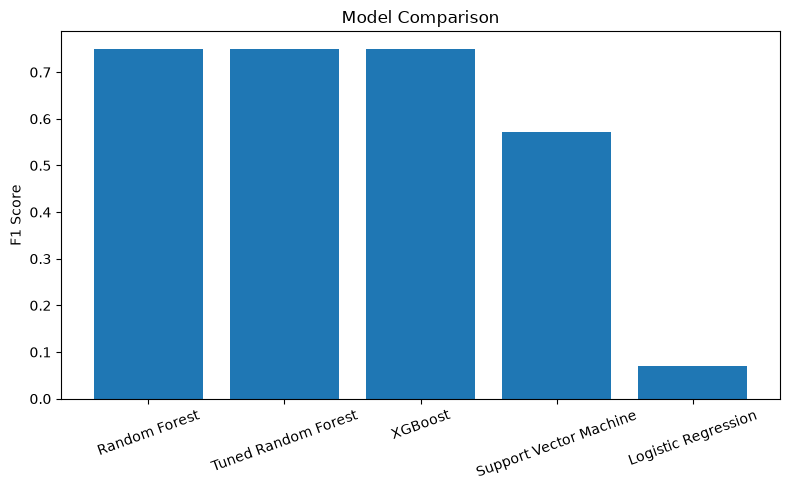

In [70]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["F1 Score"]
)

plt.ylabel("F1 Score")

plt.title("Model Comparison")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

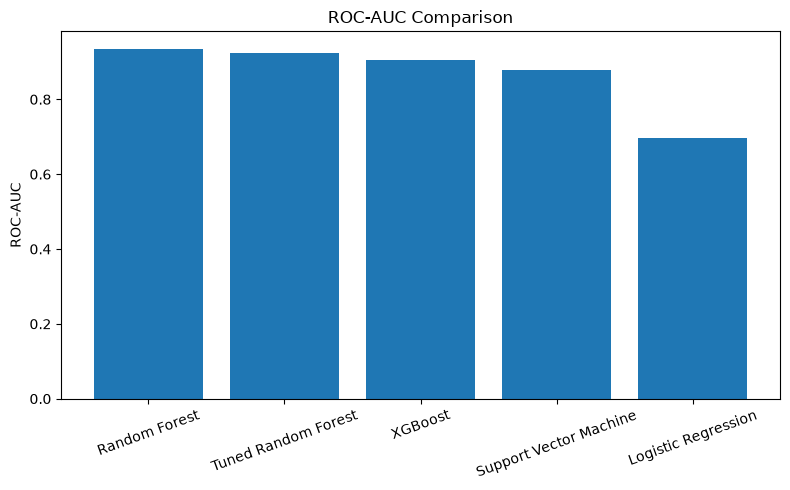

In [71]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["ROC-AUC"]
)

plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Feature Importance

In [72]:
importance = pd.DataFrame({
    "Feature": X_train_tree.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
1,median,0.173460
18,negative_ratio,0.127365
17,positive_ratio,0.085058
13,spectral_entropy,0.051128
14,lag1_autocorrelation,0.050249
6,skewness,0.042811
27,quartile_dispersion,0.030319
2,std,0.029648
3,minimum,0.028816
19,crest_factor,0.026567


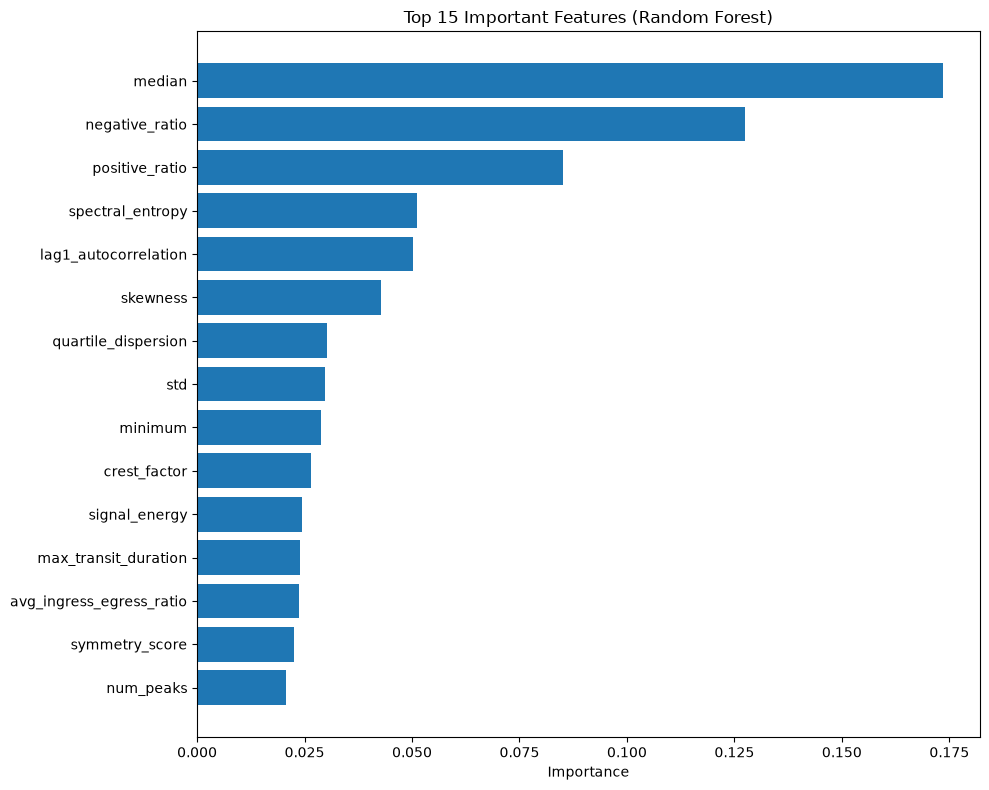

In [73]:
plt.figure(figsize=(10,8))
plt.barh(importance["Feature"][:15][::-1], importance["Importance"][:15][::-1])

plt.xlabel("Importance")
plt.title("Top 15 Important Features (Random Forest)")
plt.tight_layout()
plt.show()

# Voting Classifier

Soft Voting Classifier
Accuracy : 0.9965
Precision: 1.0000
Recall   : 0.6000
F1 Score : 0.7500
ROC-AUC  : 0.9285

Classification Report

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       565
         1.0       1.00      0.60      0.75         5

    accuracy                           1.00       570
   macro avg       1.00      0.80      0.87       570
weighted avg       1.00      1.00      1.00       570



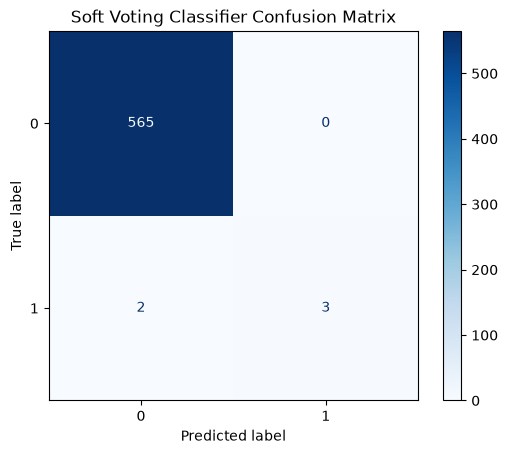

In [74]:
voting = VotingClassifier(estimators=[("rf", rf), ("xgb", xgb), ("svm", svm)], voting="soft", n_jobs=-1)
voting_results = evaluate_model(voting, X_train_tree, X_test_tree, y_train, y_test, "Soft Voting Classifier")

# Deep Learning (1D CNN)

In [75]:
import tensorflow as tf
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    GlobalAveragePooling1D,
    Input
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

2026-09-08 22:51:06.027694: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [76]:
X_train_cnn = train_df.iloc[:, 1:].values.astype(np.float32)
X_test_cnn = test_df.iloc[:, 1:].values.astype(np.float32)

y_train_cnn = train_df["LABEL"].values.astype(np.int32)
y_test_cnn = test_df["LABEL"].values.astype(np.int32)

X_train_cnn = (X_train_cnn - X_train_cnn.mean(axis=1, keepdims=True)) / (X_train_cnn.std(axis=1, keepdims=True) + 1e-8)
X_test_cnn = (X_test_cnn - X_test_cnn.mean(axis=1, keepdims=True)) / (X_test_cnn.std(axis=1, keepdims=True) + 1e-8)

X_train_cnn = X_train_cnn.reshape((-1, 3197, 1))
X_test_cnn = X_test_cnn.reshape((-1, 3197, 1))

print(X_train_cnn.shape)
print(X_test_cnn.shape)
print(np.unique(y_train_cnn))

(5087, 3197, 1)
(570, 3197, 1)
[0 1]


In [77]:
class_weights = {
    0: 1.0,
    1: 12.0
}

print(class_weights)

{0: 1.0, 1: 12.0}


In [78]:
cnn = Sequential([
    Input(shape=(3197,1)),
    Conv1D(filters=32, kernel_size=7, activation="relu", padding="same"),

    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.30),
    Conv1D(filters=64, kernel_size=5, activation="relu", padding="same"),

    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.30),

    Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),

    BatchNormalization(),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.40),
    Dense(1, activation="sigmoid")
])

In [79]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [80]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3197, 32)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3197, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1598, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1598, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1598, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1598, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 799, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 799, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 799, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 799, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,777 (108.50 KB)

 Trainable params: 27,457 (107.25 KB)

 Non-trainable params: 320 (1.25 KB)

In [81]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    verbose=1,
    min_lr=1e-6
)

In [82]:
history = cnn.fit(
    X_train_cnn,
    y_train_cnn,
    # validation_split = 0.2,
    epochs = 50,
    batch_size = 32,
    class_weight=class_weights,

    callbacks = [
        early_stop,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 31s 177ms/step - accuracy: 0.9829 - auc: 0.5371 - loss: 0.3932 - precision: 0.0370 - recall: 0.0541 - learning_rate: 0.0010
Epoch 2/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 24s 151ms/step - accuracy: 0.9841 - auc: 0.6419 - loss: 0.3192 - precision: 0.0000e+00 - recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 25s 155ms/step - accuracy: 0.9910 - auc: 0.7235 - loss: 0.2874 - precision: 0.0909 - recall: 0.0270 - learning_rate: 0.0010
Epoch 4/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 25s 160ms/step - accuracy: 0.9921 - auc: 0.8418 - loss: 0.2376 - precision: 0.0000e+00 - recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 25s 160ms/step - accuracy: 0.9925 - auc: 0.7798 - loss: 0.2609 - precision: 0.0000e+00 - recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 6/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 26s 161ms/step - accuracy: 0.9886 - auc: 0.8481 - loss: 0.2309 - precision: 0.0000e+00 - recall: 0.0000e+00 - learni

In [83]:
history.history.keys()

dict_keys(['accuracy', 'auc', 'loss', 'precision', 'recall', 'learning_rate'])

In [84]:
cnn.evaluate(X_test_cnn, y_test_cnn)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0017 - precision: 1.0000 - recall: 1.0000


[0.001749595277942717, 1.0, 1.0, 1.0, 1.0]

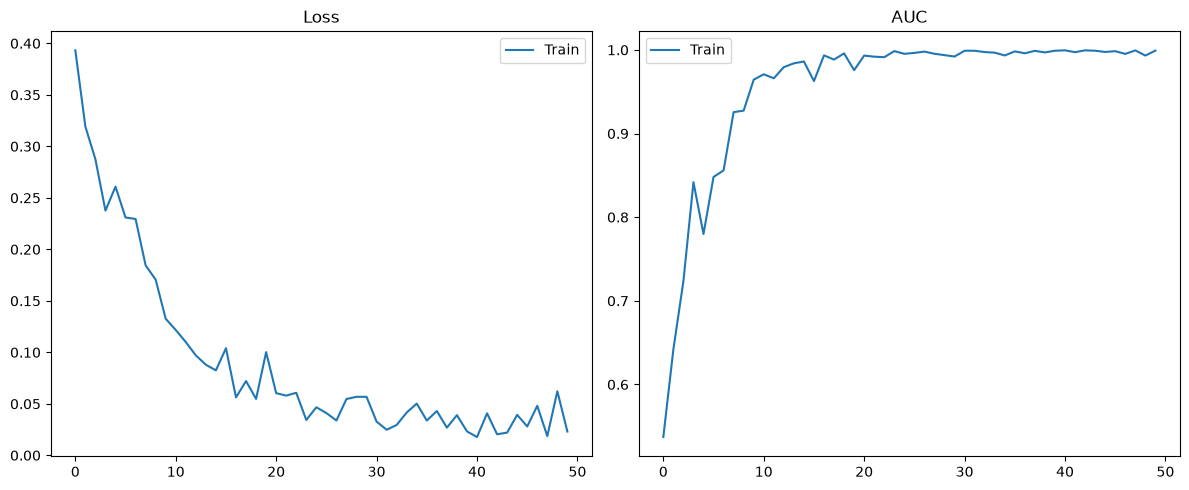

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train")
# plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["auc"], label="Train")
# plt.plot(history.history["val_auc"], label="Validation")
plt.title("AUC")
plt.legend()

plt.tight_layout()
plt.show()

In [86]:
print(class_weights)

{0: 1.0, 1: 12.0}


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
Minimum : 3.5735068e-24
Maximum : 1.0


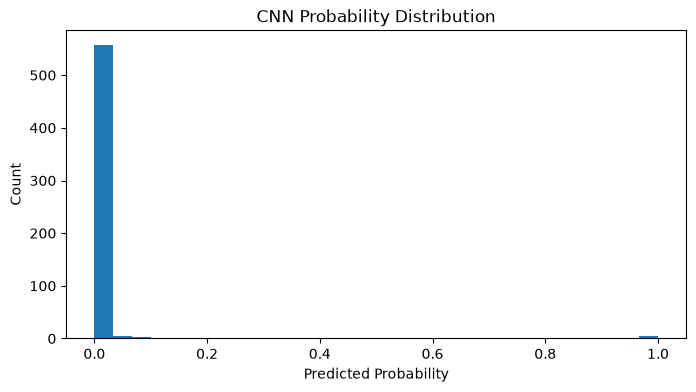

In [87]:
y_prob = cnn.predict(X_test_cnn)

print("Minimum :", y_prob.min())
print("Maximum :", y_prob.max())

plt.figure(figsize=(8,4))
plt.hist(y_prob, bins=30)
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("CNN Probability Distribution")
plt.show()

In [88]:
log_prob = log_reg.predict_proba(X_test_selected)[:, 1]
rf_prob = rf.predict_proba(X_test_selected)[:, 1]
rf_tuned_prob = best_rf.predict_proba(X_test_selected)[:, 1]
xgb_prob = xgb.predict_proba(X_test_selected)[:, 1]
svm_prob = svm.predict_proba(X_test_selected)[:, 1]
cnn_prob = cnn.predict(X_test_cnn).ravel()

print("Probability extraction complete!")

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
Probability extraction complete!


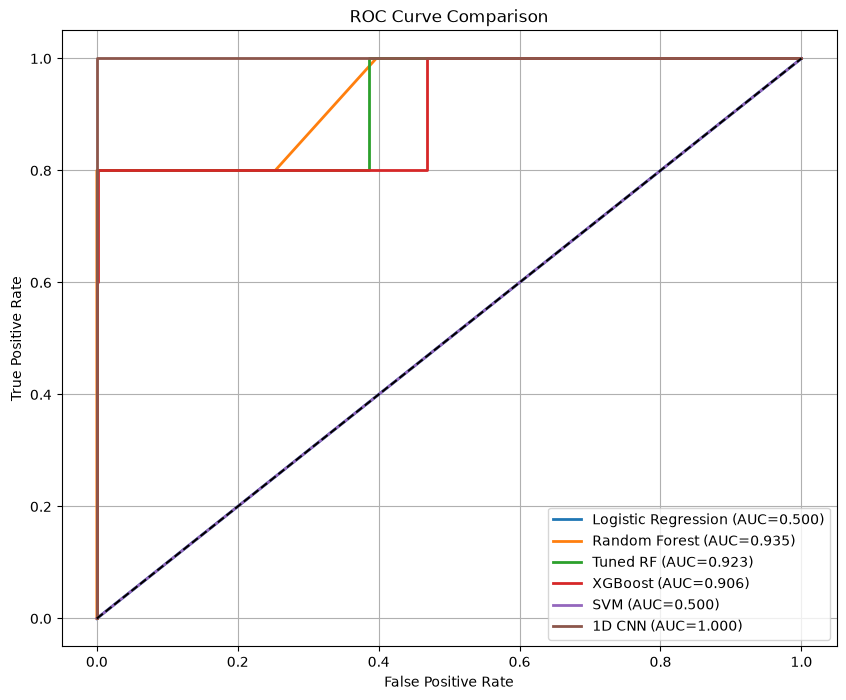

In [89]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

plt.figure(figsize=(10,8))

models = {
    "Logistic Regression":log_prob,
    "Random Forest":rf_prob,
    "Tuned RF":rf_tuned_prob,
    "XGBoost":xgb_prob,
    "SVM":svm_prob,
    "1D CNN":cnn_prob
}

for name,prob in models.items():
    fpr,tpr,_ = roc_curve(y_test,prob)
    roc_auc = auc(fpr,tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

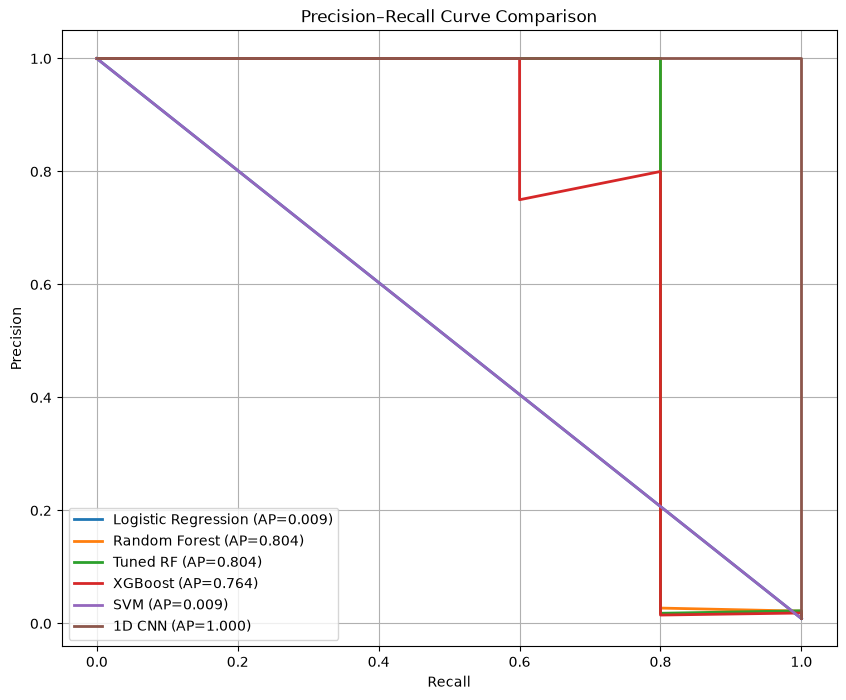

In [90]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

plt.figure(figsize=(10,8))

for name, prob in models.items():

    precision, recall, _ = precision_recall_curve(y_test, prob)

    ap = average_precision_score(y_test, prob)

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{name} (AP={ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [91]:
cnn.save("data/cnn_exoplanet.keras")

## 10. Soft Voting Ensemble

In [92]:
voting = VotingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        )),

        ("xgb", XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )),

        ("svm", SVC(
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ],
    voting="soft"
)

In [93]:
voting.fit(X_train_selected, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[float64](2,)","[0.,1.]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[RandomForestC...ndom_state=42), XGBClassifier...ree=None, ...), SVC(class_wei...ndom_state=42)]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,33


In [94]:
y_pred = voting.predict(X_test_selected)

y_prob = voting.predict_proba(X_test_selected)[:,1]

In [95]:
voting = VotingClassifier(
    estimators=[
        ("rf", best_rf),
        ("xgb", xgb),
        ("svm", svm)
    ],
    voting="soft"
)

Voting Ensemble
Accuracy : 0.9965
Precision: 1.0000
Recall   : 0.6000
F1 Score : 0.7500
ROC-AUC  : 0.9129

Classification Report

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       565
         1.0       1.00      0.60      0.75         5

    accuracy                           1.00       570
   macro avg       1.00      0.80      0.87       570
weighted avg       1.00      1.00      1.00       570



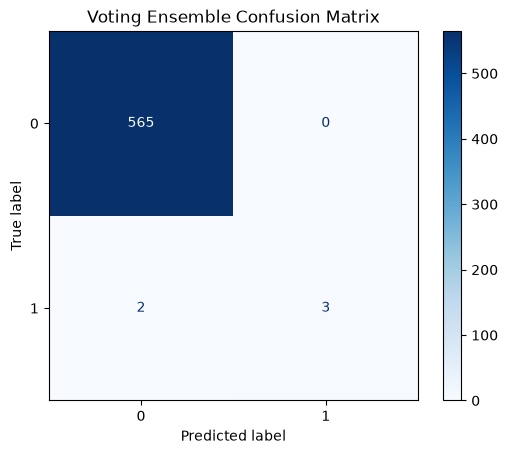

In [96]:
voting_results = evaluate_model(
    voting,
    X_train_final,
    X_test_final,
    y_train,
    y_test,
    "Voting Ensemble"
)

In [ ]:
from sklearn.inspection import permutation_importance

In [103]:
perm = permutation_importance(
    best_rf,
    X_test_final,
    y_test,
    n_repeats=20,
    scoring="f1",
    random_state=42,
    n_jobs=1
)

In [99]:
importance_df = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": perm.importances_mean,
    "Std": perm.importances_std
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance,Std
18,negative_ratio,0.430952,2.182179e-02
1,median,0.178571,5.551115e-17
17,positive_ratio,0.178571,5.551115e-17
24,percentile_ratio,0.000000,0.000000e+00
19,crest_factor,0.000000,0.000000e+00
20,impulse_factor,0.000000,0.000000e+00
21,num_peaks,0.000000,0.000000e+00
22,avg_peak_width,0.000000,0.000000e+00
23,peak_spacing,0.000000,0.000000e+00
0,mean,0.000000,0.000000e+00


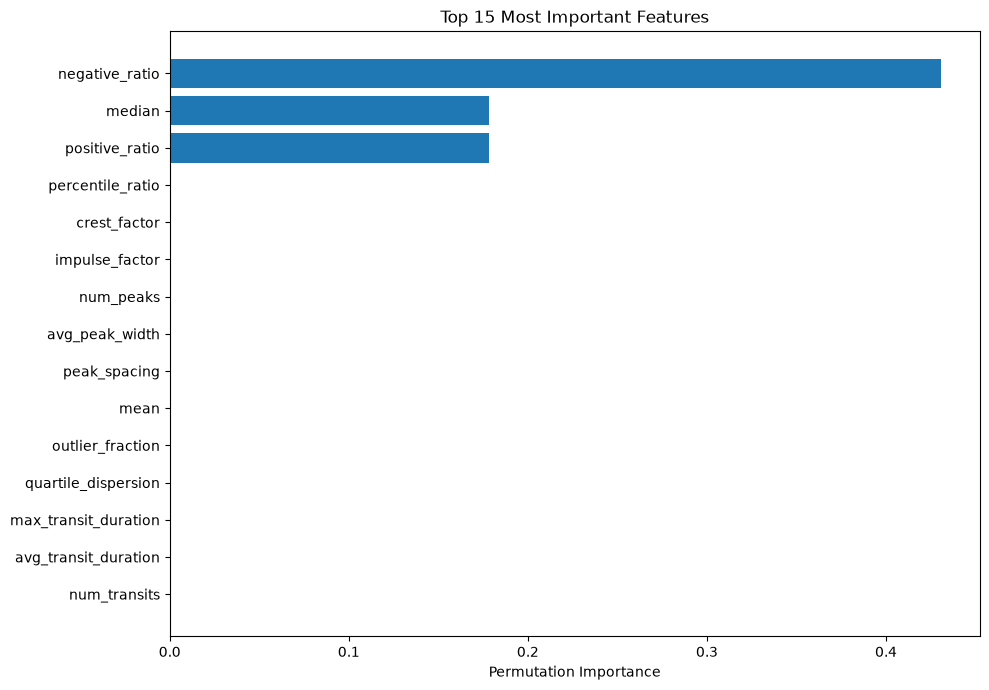

In [100]:
plt.figure(figsize=(10,7))

plt.barh(
    importance_df["Feature"][:15][::-1],
    importance_df["Importance"][:15][::-1]
)

plt.xlabel("Permutation Importance")
plt.title("Top 15 Most Important Features")

plt.tight_layout()
plt.show()

In [101]:
joblib.dump(best_rf, "data/best_rf.pkl")
joblib.dump(selector, "data/selector.pkl")
joblib.dump(scaler, "data/scaler.pkl")

['data/scaler.pkl']

## Error Analysis

Run the next cell after saving the models. It identifies false-negative planets in the held-out test set and reports their probabilities. The CNN result is included when TensorFlow is installed.

In [104]:
from error_analysis import run_error_analysis
error_report = run_error_analysis()
error_report

# Current saved-RF result: samples 0 and 3 are missed (probabilities about 0.14% and 16.84%).

{'random_forest_misses': [0, 3],
 'random_forest_probabilities': [0.0014216275054425341, 0.168426218175591],
 'cnn_misses': [],
 'cnn_probabilities': []}

## Save All Models and Select the Deployment Model

The next two cells do not retrain or change feature extraction. They record CNN metrics, save the trained objects using their existing names, and select one deployment model by F1 score (then ROC-AUC and recall to break ties). Run them after every prior training cell.

In [105]:
# CNN uses raw, per-light-curve normalized data rather than extracted tabular features.
cnn_prob = cnn.predict(X_test_cnn, verbose=0).ravel()
cnn_pred = (cnn_prob >= 0.5).astype(int)

cnn_results = {
    "Model": "1D CNN",
    "Accuracy": accuracy_score(y_test_cnn, cnn_pred),
    "Precision": precision_score(y_test_cnn, cnn_pred, zero_division=0),
    "Recall": recall_score(y_test_cnn, cnn_pred, zero_division=0),
    "F1 Score": f1_score(y_test_cnn, cnn_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_cnn, cnn_prob),
    "Predictions": cnn_pred
}

cnn_results

{'Model': '1D CNN',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1 Score': 1.0,
 'ROC-AUC': 1.0,
 'Predictions': array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [106]:
import json

# Keep your existing object names. This only creates reusable inference artifacts.
comparison = pd.DataFrame([
    log_results,
    rf_results,
    best_rf_results,
    xgb_results,
    svm_results,
    voting_results,
    cnn_results
])

# Accuracy is misleading for this imbalanced dataset, so deployment selection uses F1.
ranking = comparison.sort_values(
    by=["F1 Score", "ROC-AUC", "Recall"],
    ascending=False
).reset_index(drop=True)

model_scores = ranking[["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]]
model_scores.to_csv("data/model_comparison.csv", index=False)
best_model_name = model_scores.iloc[0]["Model"]

joblib.dump(log_reg, "data/log_reg.pkl")
joblib.dump(rf, "data/rf.pkl")
joblib.dump(best_rf, "data/best_rf.pkl")
joblib.dump(xgb, "data/xgb.pkl")
joblib.dump(svm, "data/svm.pkl")
joblib.dump(voting, "data/voting.pkl")
joblib.dump(selector, "data/selector.pkl")
joblib.dump(scaler, "data/scaler.pkl")
cnn.save("data/cnn_exoplanet.keras")

model_selection = {
    "best_model": best_model_name,
    "selection_metric": "F1 Score",
    "selection_dataset": "exoTest.csv (held-out evaluation)",
    "ranking": model_scores.to_dict(orient="records")
}

with open("data/model_selection.json", "w") as file:
    json.dump(model_selection, file, indent=2)

print(f"Deployment model selected by F1 Score: {best_model_name}")
model_scores

Deployment model selected by F1 Score: 1D CNN


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1D CNN,1.000000,1.000000,1.0,1.000000,1.000000
1,Random Forest,0.996491,1.000000,0.6,0.750000,0.935044
2,Tuned Random Forest,0.996491,1.000000,0.6,0.750000,0.922832
3,Voting Ensemble,0.996491,1.000000,0.6,0.750000,0.912920
4,XGBoost,0.996491,1.000000,0.6,0.750000,0.905841
5,Support Vector Machine,0.989474,0.444444,0.8,0.571429,0.878230
6,Logistic Regression,0.859649,0.037037,0.6,0.069767,0.697345
